<a href="https://colab.research.google.com/github/Mouni178/Python-Programming/blob/main/Simple_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [50]:
#Create the dataset
data={
    "text": [
        "I love this movie",
        "This movie is amazing",
        "I really enjoyed the movie",
        "This is a wonderful movie",
        "The movie was fantastic",
        "I liked this movie",
        "This movie is excellent",
        "I enjoyed watching this",
        "What a great movie",
        "This was a beautiful experience",

        "I hate this movie",
        "This movie is terrible",
        "I really disliked the movie",
        "This is a horrible movie",
        "The movie was boring",
        "I did not like this movie",
        "This movie is bad",
        "I hated watching this",
        "What a terrible movie",
        "This was a disappointing experience"
    ],
    "label": [
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0
    ]
}
df=pd.DataFrame(data)
print(df)


                                   text  label
0                     I love this movie      1
1                 This movie is amazing      1
2            I really enjoyed the movie      1
3             This is a wonderful movie      1
4               The movie was fantastic      1
5                    I liked this movie      1
6               This movie is excellent      1
7               I enjoyed watching this      1
8                    What a great movie      1
9       This was a beautiful experience      1
10                    I hate this movie      0
11               This movie is terrible      0
12          I really disliked the movie      0
13             This is a horrible movie      0
14                 The movie was boring      0
15            I did not like this movie      0
16                    This movie is bad      0
17                I hated watching this      0
18                What a terrible movie      0
19  This was a disappointing experience      0


In [12]:
df.head()

,text,label
0,I love this movie,1
1,This movie is amazing,1
2,I really enjoyed the movie,1
3,This is a wonderful movie,1
4,The movie was fantastic,1


In [13]:
df.tail()

,text,label
15,I did not like this movie,0
16,This movie is bad,0
17,I hated watching this,0
18,What a terrible movie,0
19,This was a disappointing experience,0


In [15]:
#Seperate X and y
X=df["text"]
y=df["label"]

In [16]:
X

,text
0,I love this movie
1,This movie is amazing
2,I really enjoyed the movie
3,This is a wonderful movie
4,The movie was fantastic
5,I liked this movie
6,This movie is excellent
7,I enjoyed watching this
8,What a great movie
9,This was a beautiful experience


In [17]:
y

,label
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [20]:
#Import tokenizer and padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [28]:
#create tokenizer
tokenizer = Tokenizer(
    num_words=100,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(X)
tokenizer.word_index

{'<OOV>': 1,
 'movie': 2,
 'this': 3,
 'i': 4,
 'is': 5,
 'a': 6,
 'the': 7,
 'was': 8,
 'really': 9,
 'enjoyed': 10,
 'watching': 11,
 'what': 12,
 'experience': 13,
 'terrible': 14,
 'love': 15,
 'amazing': 16,
 'wonderful': 17,
 'fantastic': 18,
 'liked': 19,
 'excellent': 20,
 'great': 21,
 'beautiful': 22,
 'hate': 23,
 'disliked': 24,
 'horrible': 25,
 'boring': 26,
 'did': 27,
 'not': 28,
 'like': 29,
 'bad': 30,
 'hated': 31,
 'disappointing': 32}

In [31]:
#Convert text into ssequences
sequences = tokenizer.texts_to_sequences(X)
sequences[:5]

[[4, 15, 3, 2],
 [3, 2, 5, 16],
 [4, 9, 10, 7, 2],
 [3, 5, 6, 17, 2],
 [7, 2, 8, 18]]

In [33]:
#Padding
X_padded = pad_sequences(
    sequences,
    padding="post"
)
X_padded

array([[ 4, 15,  3,  2,  0,  0],
       [ 3,  2,  5, 16,  0,  0],
       [ 4,  9, 10,  7,  2,  0],
       [ 3,  5,  6, 17,  2,  0],
       [ 7,  2,  8, 18,  0,  0],
       [ 4, 19,  3,  2,  0,  0],
       [ 3,  2,  5, 20,  0,  0],
       [ 4, 10, 11,  3,  0,  0],
       [12,  6, 21,  2,  0,  0],
       [ 3,  8,  6, 22, 13,  0],
       [ 4, 23,  3,  2,  0,  0],
       [ 3,  2,  5, 14,  0,  0],
       [ 4,  9, 24,  7,  2,  0],
       [ 3,  5,  6, 25,  2,  0],
       [ 7,  2,  8, 26,  0,  0],
       [ 4, 27, 28, 29,  3,  2],
       [ 3,  2,  5, 30,  0,  0],
       [ 4, 31, 11,  3,  0,  0],
       [12,  6, 14,  2,  0,  0],
       [ 3,  8,  6, 32, 13,  0]], dtype=int32)

In [35]:
#Train_tese_split
X_train, X_test, y_train, y_test = train_test_split(X_padded,y,test_size=0.2,random_state=42)
model = Sequential()

In [53]:
#Build RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,SimpleRNN


In [54]:
model = Sequential()

model.add(
    Embedding(
        input_dim=len(tokenizer.word_index)+1, output_dim=16))
model.add(SimpleRNN(32))

model.add(Dense(1, activation="sigmoid"))

In [55]:
#Complile
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [56]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
#Train RNN
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9375 - loss: 0.4382 - val_accuracy: 0.2500 - val_loss: 0.8777
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9375 - loss: 0.4212 - val_accuracy: 0.2500 - val_loss: 0.8941
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9375 - loss: 0.4037 - val_accuracy: 0.2500 - val_loss: 0.9119
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9375 - loss: 0.3857 - val_accuracy: 0.2500 - val_loss: 0.9312
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9375 - loss: 0.3674 - val_accuracy: 0.2500 - val_loss: 0.9512
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 0.3488 - val_accuracy: 0.2500 - val_loss: 0.9704
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.3301 - val_accuracy: 0.2500 - val_loss: 0.9890
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 1.0000 - loss: 0.3112 - val_accuracy: 0.2500 - val_loss: 

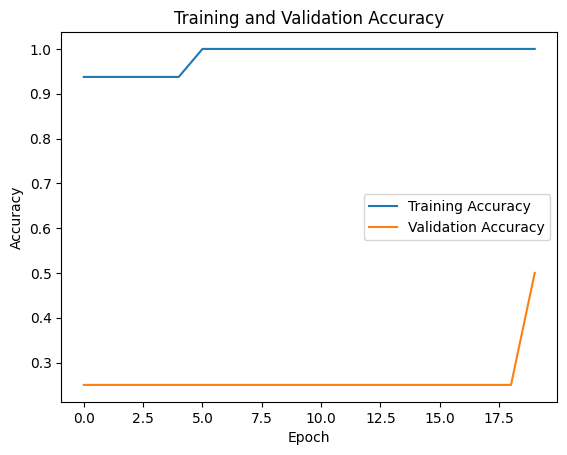

In [62]:
#Accuray vs epoch
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

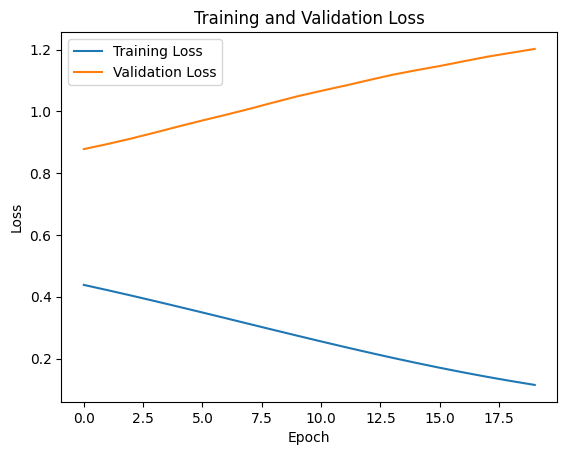

In [63]:
#plot loss vs epoch
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [64]:
#Evalute on test data
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

print(
    "Final Test Accuracy: {:.2f}%".format(
        accuracy * 100
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 1.2019
Test Loss: 1.2019304037094116
Test Accuracy: 0.5
Final Test Accuracy: 50.00%


In [67]:
#Test 3 sentences
def predict_sentiment(text):

    # Convert text into integer sequence
    sequence = tokenizer.texts_to_sequences([text])

    # Pad the sequence
    padded_sequence = pad_sequences(
        sequence,
        padding="post",
        maxlen=X_train.shape[1]
    )

    # Get prediction
    prediction = model.predict(
        padded_sequence,
        verbose=0
    )

    # Convert probability into sentiment
    if prediction[0][0] >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", text)
    print("Prediction Score:", prediction[0][0])
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

    return sentiment
predict_sentiment("I really loved watching this film")
predict_sentiment("This film was extremely boring")
predict_sentiment("The movie was fantastic and enjoyable")

Review: I really loved watching this film
Prediction Score: 0.48682052
Predicted Sentiment: Negative
--------------------------------------------------
Review: This film was extremely boring
Prediction Score: 0.5158841
Predicted Sentiment: Positive
--------------------------------------------------
Review: The movie was fantastic and enjoyable
Prediction Score: 0.83309585
Predicted Sentiment: Positive
--------------------------------------------------


'Positive'